# 03 — OCR Engine Comparison

Comparação entre PaddleOCR e Tesseract no dataset CORD-v2.

Baseado nos resultados do Exp 6 (já executado via `run_experiments.py`).

Métricas:
- CER (Character Error Rate)
- WER (Word Error Rate)
- Latência por imagem

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RESULTS_DIR = Path('../results')

# Load experiment results
with open(RESULTS_DIR / 'metrics' / 'experiments.json') as f:
    experiments = json.load(f)

exp6 = experiments['exp6']
print('Engines:', list(exp6.keys()))

Engines: ['PaddleOCR', 'Tesseract']


## 1. CER e WER por Engine

In [2]:
engines = list(exp6.keys())
cer_means = [exp6[e]['cer_mean'] for e in engines]
wer_means = [exp6[e]['wer_mean'] for e in engines]
avg_times = [exp6[e]['avg_time'] for e in engines]

print(f"{'Engine':<12} {'CER':>8} {'WER':>8} {'Latency':>10}")
print('-' * 42)
for e, cer, wer, t in zip(engines, cer_means, wer_means, avg_times):
    print(f"{e:<12} {cer:>8.3f} {wer:>8.3f} {t:>8.1f}s")

Engine            CER      WER    Latency
------------------------------------------
PaddleOCR       0.158    0.259     12.2s
Tesseract       0.667    1.155      0.7s


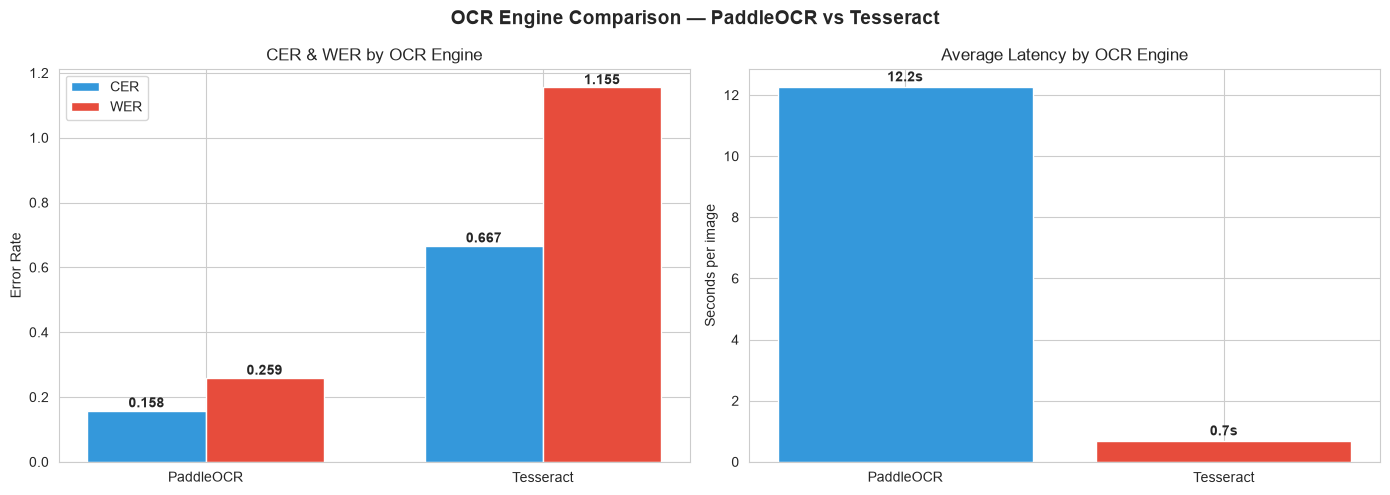

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#e74c3c']

# CER & WER
x = np.arange(len(engines))
width = 0.35
bars1 = ax1.bar(x - width/2, cer_means, width, label='CER', color=colors[0])
bars2 = ax1.bar(x + width/2, wer_means, width, label='WER', color=colors[1])
ax1.set_xticks(x)
ax1.set_xticklabels(engines)
ax1.set_ylabel('Error Rate')
ax1.set_title('CER & WER by OCR Engine')
ax1.legend()
for bar in bars1 + bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontweight='bold')

# Latency
ax2.bar(engines, avg_times, color=colors)
ax2.set_ylabel('Seconds per image')
ax2.set_title('Average Latency by OCR Engine')
for i, t in enumerate(avg_times):
    ax2.text(i, t + 0.2, f'{t:.1f}s', ha='center', fontweight='bold')

plt.suptitle('OCR Engine Comparison — PaddleOCR vs Tesseract', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'ocr_comparison_detailed.png', bbox_inches='tight')
plt.show()

## 2. Distribuição de CER por Imagem

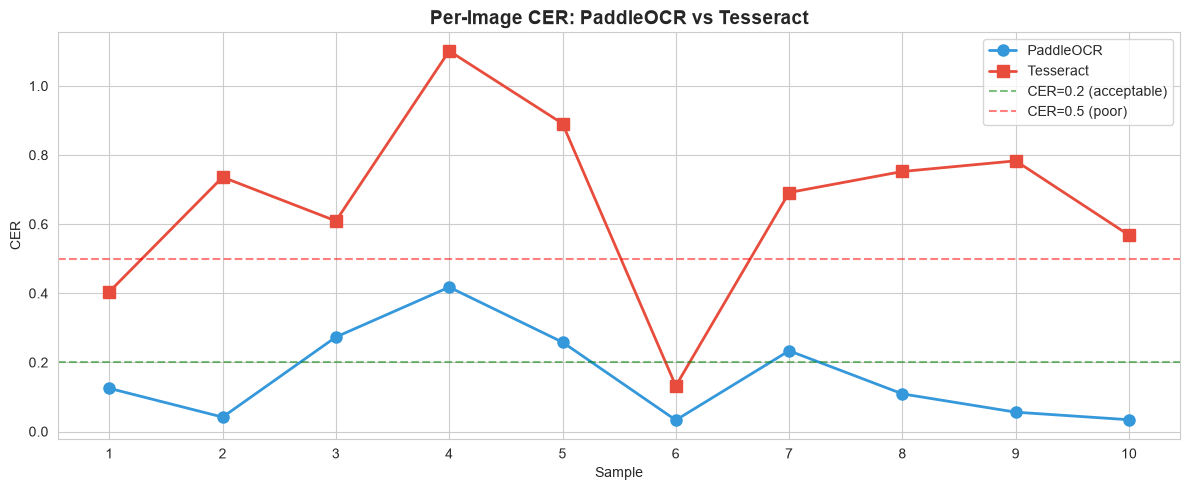

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

paddle_cer = exp6['PaddleOCR']['cer_scores']
tesseract_cer = exp6['Tesseract']['cer_scores']
samples = list(range(1, len(paddle_cer) + 1))

ax.plot(samples, paddle_cer, 'o-', color='#3498db', markersize=8, linewidth=2, label='PaddleOCR')
ax.plot(samples, tesseract_cer, 's-', color='#e74c3c', markersize=8, linewidth=2, label='Tesseract')

ax.axhline(y=0.2, color='green', linestyle='--', alpha=0.5, label='CER=0.2 (acceptable)')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='CER=0.5 (poor)')

ax.set_xlabel('Sample')
ax.set_ylabel('CER')
ax.set_title('Per-Image CER: PaddleOCR vs Tesseract', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(samples)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'ocr_per_image_cer.png', bbox_inches='tight')
plt.show()

## 3. Box Plot de CER

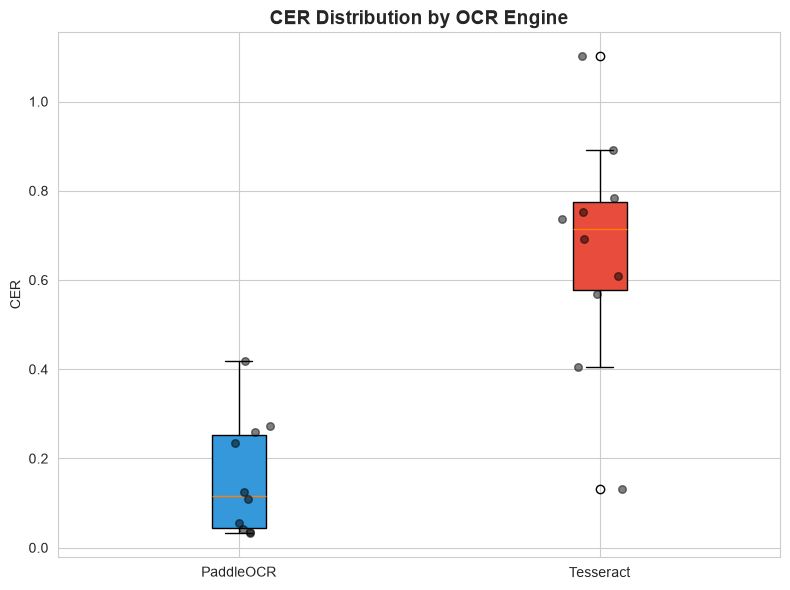

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

data = [paddle_cer, tesseract_cer]
bp = ax.boxplot(data, tick_labels=engines, patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')

ax.set_ylabel('CER')
ax.set_title('CER Distribution by OCR Engine', fontsize=14, fontweight='bold')

# Add individual points
for i, d in enumerate(data):
    x = np.random.normal(i+1, 0.04, size=len(d))
    ax.scatter(x, d, alpha=0.5, s=30, color='black', zorder=5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'ocr_cer_boxplot.png', bbox_inches='tight')
plt.show()

## 4. Resumo

In [6]:
print('=' * 50)
print('OCR COMPARISON SUMMARY')
print('=' * 50)
print(f'''
PaddleOCR:
  - CER: {exp6["PaddleOCR"]["cer_mean"]:.3f} (median: {np.median(paddle_cer):.3f})
  - WER: {exp6["PaddleOCR"]["wer_mean"]:.3f}
  - Latency: {exp6["PaddleOCR"]["avg_time"]:.1f}s/image

Tesseract:
  - CER: {exp6["Tesseract"]["cer_mean"]:.3f} (median: {np.median(tesseract_cer):.3f})
  - WER: {exp6["Tesseract"]["wer_mean"]:.3f}
  - Latency: {exp6["Tesseract"]["avg_time"]:.1f}s/image

Conclusion:
  - PaddleOCR is {exp6["Tesseract"]["cer_mean"]/exp6["PaddleOCR"]["cer_mean"]:.1f}x better in CER
  - Tesseract is {exp6["PaddleOCR"]["avg_time"]/exp6["Tesseract"]["avg_time"]:.0f}x faster
  - PaddleOCR is the clear winner for quality-sensitive applications
''')

OCR COMPARISON SUMMARY

PaddleOCR:
  - CER: 0.158 (median: 0.117)
  - WER: 0.259
  - Latency: 12.2s/image

Tesseract:
  - CER: 0.667 (median: 0.714)
  - WER: 1.155
  - Latency: 0.7s/image

Conclusion:
  - PaddleOCR is 4.2x better in CER
  - Tesseract is 18x faster
  - PaddleOCR is the clear winner for quality-sensitive applications

